# CMSC320 final project checkpoint 2




In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [10]:
file_path = "diabetes_binary_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [11]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types before cleaning:")
print(df.dtypes)

Shape of dataset:
(253680, 22)

Column names:
Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

Data types before cleaning:
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex         

In [12]:
# remove extra spaces from column names
df.columns = df.columns.str.strip()

# convert every column to numeric just in case
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing values in each column:")
print(df.isna().sum())

Missing values in each column:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [13]:
# drop missing values
df = df.dropna()

# convert columns to integers since this dataset is coded numerically
for col in df.columns:
    df[col] = df[col].astype(int)

print("Shape after cleaning:")
print(df.shape)

print("\nData types after cleaning:")
print(df.dtypes)

print("\nFirst 5 rows after preprocessing:")
print(df.head())

Shape after cleaning:
(253680, 22)

Data types after cleaning:
Diabetes_binary         int64
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

First 5 rows after preprocessing:
   Diabetes_binary  HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  \
0                0       1         1          1   40       1       0   
1                0       0         0          0   25       1       0   
2           

## 4. Basic data exploration and summary statistics

In [14]:
summary_stats = df.describe()
summary_stats

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [15]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nClass counts for Diabetes_binary:")
print(df["Diabetes_binary"].value_counts().sort_index())

Number of rows: 253680
Number of columns: 22

Class counts for Diabetes_binary:
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64


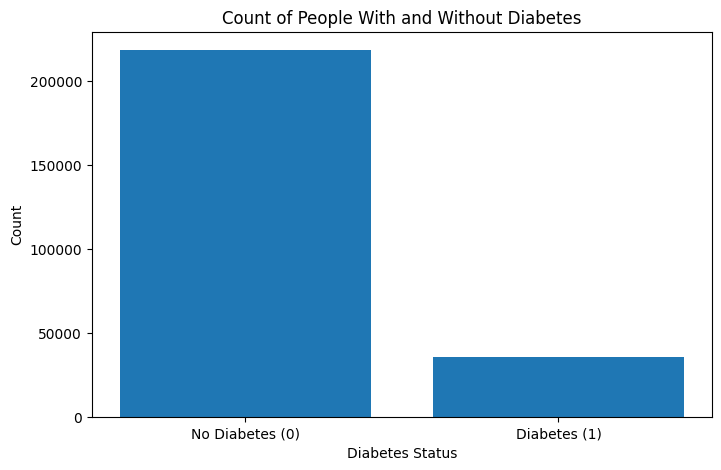

In [16]:
diabetes_counts = df["Diabetes_binary"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(["No Diabetes (0)", "Diabetes (1)"], diabetes_counts.values)
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.title("Count of People With and Without Diabetes")
plt.show()

### Quick conclusion from exploration
This dataset is large, fully numeric after preprocessing, and has a binary target variable (`Diabetes_binary`), so group comparisons and hypothesis tests are appropriate.

In [17]:
correlation_with_diabetes = df.corr()["Diabetes_binary"].sort_values(ascending=False)
print(correlation_with_diabetes)

Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919
Name: Diabetes_binary, dtype: float64


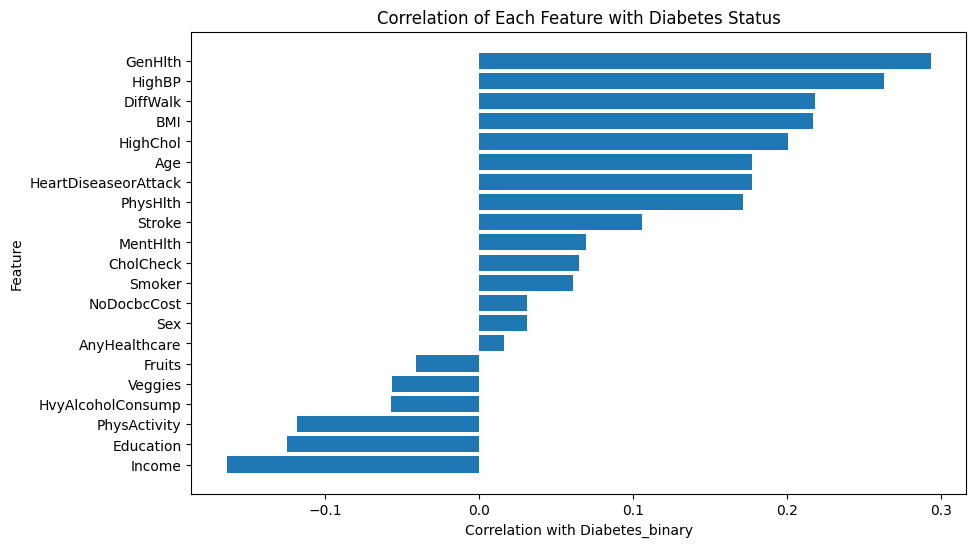

In [18]:
corr_to_target = correlation_with_diabetes.drop("Diabetes_binary").sort_values()

plt.figure(figsize=(10,6))
plt.barh(corr_to_target.index, corr_to_target.values)
plt.xlabel("Correlation with Diabetes_binary")
plt.ylabel("Feature")
plt.title("Correlation of Each Feature with Diabetes Status")
plt.show()

## 5. Statistical Method 1: One-tailed t-test

### Question
Do people with diabetes have a higher average BMI than people without diabetes?

### Hypotheses
- H0: The mean BMI for people with diabetes is less than or equal to the mean BMI for people without diabetes.
- HA: The mean BMI for people with diabetes is greater than the mean BMI for people without diabetes.

In [19]:
no_diabetes_bmi = df[df["Diabetes_binary"] == 0]["BMI"]
diabetes_bmi = df[df["Diabetes_binary"] == 1]["BMI"]

print("Mean BMI for no diabetes group:", no_diabetes_bmi.mean())
print("Mean BMI for diabetes group:", diabetes_bmi.mean())

Mean BMI for no diabetes group: 27.80577005871738
Mean BMI for diabetes group: 31.94401063769592


/tmp/ipykernel_2884/3800679776.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_diabetes_bmi, diabetes_bmi], labels=["No Diabetes", "Diabetes"])


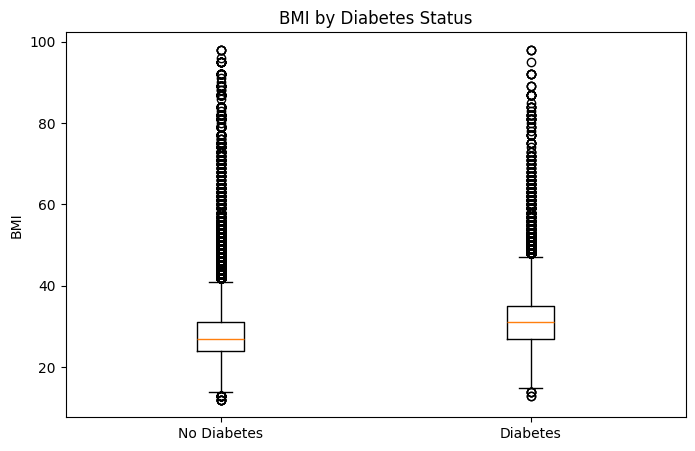

In [20]:
plt.figure(figsize=(8,5))
plt.boxplot([no_diabetes_bmi, diabetes_bmi], labels=["No Diabetes", "Diabetes"])
plt.ylabel("BMI")
plt.title("BMI by Diabetes Status")
plt.show()

In [21]:

t_stat_1, p_two_sided_1 = stats.ttest_ind(diabetes_bmi, no_diabetes_bmi, equal_var=False)

# convert to one-tailed p-value for HA: mean(diabetes_bmi) > mean(no_diabetes_bmi)
if t_stat_1 > 0:
    p_one_tailed_1 = p_two_sided_1 / 2
else:
    p_one_tailed_1 = 1 - (p_two_sided_1 / 2)

print("t-statistic:", t_stat_1)
print("one-tailed p-value:", p_one_tailed_1)

alpha = 0.05
if p_one_tailed_1 < alpha:
    print("Conclusion: Reject H0. There is evidence that people with diabetes have a higher average BMI.")
else:
    print("Conclusion: Fail to reject H0. There is not enough evidence that people with diabetes have a higher average BMI.")

t-statistic: 99.91962872964875
one-tailed p-value: 0.0
Conclusion: Reject H0. There is evidence that people with diabetes have a higher average BMI.


## Statistical Method 2: Two-tailed t-test

### Question
Is diabetes prevalence different between males and females?



### Hypotheses
- H0: The mean is the same for males and females.
- HA: The mean  is different for males and females.

In [22]:
female_diabetes = df[df["Sex"] == 0]["Diabetes_binary"]
male_diabetes = df[df["Sex"] == 1]["Diabetes_binary"]

print("Female diabetes rate:", female_diabetes.mean())
print("Male diabetes rate:", male_diabetes.mean())

Female diabetes rate: 0.12967867355994758
Male diabetes rate: 0.1516033158469554


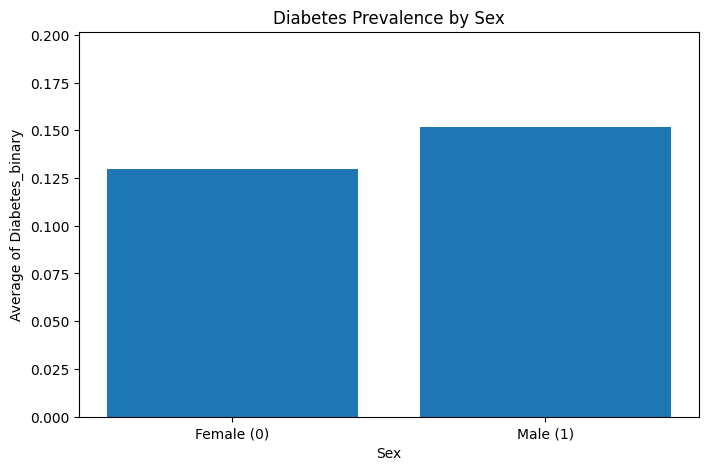

In [23]:
sex_rates = df.groupby("Sex")["Diabetes_binary"].mean()

plt.figure(figsize=(8,5))
plt.bar(["Female (0)", "Male (1)"], sex_rates.values)
plt.xlabel("Sex")
plt.ylabel("Average of Diabetes_binary")
plt.title("Diabetes Prevalence by Sex")
plt.ylim(0, max(sex_rates.values) + 0.05)
plt.show()

In [24]:
t_stat_2, p_value_2 = stats.ttest_ind(male_diabetes, female_diabetes, equal_var=False)

print("t-statistic:", t_stat_2)
print("two-tailed p-value:", p_value_2)

if p_value_2 < alpha:
    print("Conclusion: Reject H0. Diabetes prevalence is significantly different between males and females.")
else:
    print("Conclusion: Fail to reject H0. There is not enough evidence of a difference in diabetes prevalence between males and females.")

t-statistic: 15.715163471328745
two-tailed p-value: 1.2721936493685938e-55
Conclusion: Reject H0. Diabetes prevalence is significantly different between males and females.


## Statistical Method 3: ANOVA

### Question
Does average BMI differ across broad age groups?

### Hypotheses
- H0: All age groups have the same mean BMI.
- HA: At least one age group has a different mean BMI.

In [ ]:
def age_bucket(age_code):
    if age_code <= 4:
        return "Young"
    elif age_code <= 9:
        return "Middle"
    else:
        return "Older"

df["Age_Group"] = df["Age"].apply(age_bucket)

print(df["Age_Group"].value_counts())

Age_Group
Middle    126366
Older      89070
Young      38244
Name: count, dtype: int64


In [ ]:
young_bmi = df[df["Age_Group"] == "Young"]["BMI"]
middle_bmi = df[df["Age_Group"] == "Middle"]["BMI"]
older_bmi = df[df["Age_Group"] == "Older"]["BMI"]

print("Young mean BMI:", young_bmi.mean())
print("Middle mean BMI:", middle_bmi.mean())
print("Older mean BMI:", older_bmi.mean())

Young mean BMI: 27.975996234703484
Middle mean BMI: 28.893112071284996
Older mean BMI: 27.832233075109464


/var/folders/t1/rtrzhf1j47374k1rchzn7fsc0000gn/T/ipykernel_96696/3863163832.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([young_bmi, middle_bmi, older_bmi], labels=["Young", "Middle", "Older"])


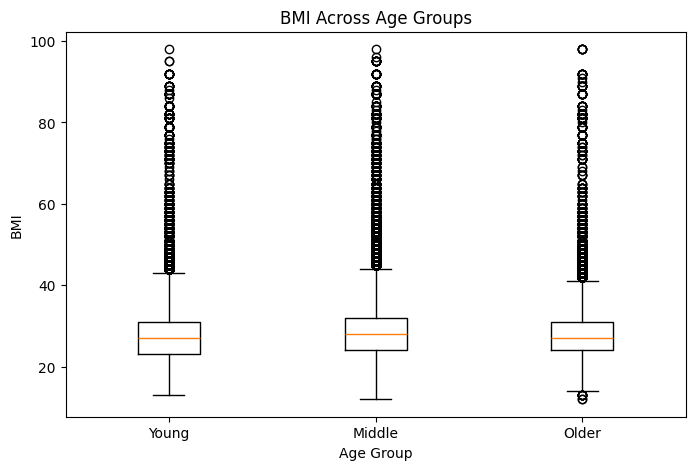

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot([young_bmi, middle_bmi, older_bmi], labels=["Young", "Middle", "Older"])
plt.xlabel("Age Group")
plt.ylabel("BMI")
plt.title("BMI Across Age Groups")
plt.show()

In [ ]:
f_stat, p_value_3 = stats.f_oneway(young_bmi, middle_bmi, older_bmi)

print("F-statistic:", f_stat)
print("p-value:", p_value_3)

if p_value_3 < alpha:
    print("Conclusion: Reject H0. At least one age group has a different mean BMI.")
else:
    print("Conclusion: Fail to reject H0. There is not enough evidence that mean BMI differs across age groups.")

F-statistic: 762.8424736558701
p-value: 0.0
Conclusion: Reject H0. At least one age group has a different mean BMI.


## 8. Final written conclusions

Question 1. Do people with diabetes have a higher than average BMI than those who do not? For this question, we applied a one-tailed t-test.

Hypotheses:
- H0: The mean BMI for people with diabetes is less than or equal to the mean BMI for people without diabetes.
- HA: The mean BMI for people with diabetes is greater than the mean BMI for people without diabetes.

By applying the one-tailed t-test, we obtained a p-value less than the alpha of 0.05, so we can reject the null hypothesis. In conclusion, the mean BMI for people with diabetes is greater than the mean BMI for people without diabetes.

Question 2.
Is diabetes prevalence different between males and females? For this question, we applied a two-tailed t-test

Hypotheses
- H0: The mean is the same for males and females.
- HA: The mean is different for males and females.

By applying the two-tailed t-test, we obtained a p-value less than the alpha of 0.05, so we can reject the null hypothesis. In conclusion, the mean is different for males and females.

Question 3.
Does average BMI differ across broad age groups? For this question, we applied an ANOVA test.

Hypotheses
- H0: All age groups have the same mean BMI.
- HA: At least one age group has a different mean BMI.

By applying the ANOVA test, we obtained a p-value less than the alpha of 0.05, so we can reject the null hypothesis. In conclusion, at least one age group has a different mean BMI.

